# Importar librerías

In [9]:
from google.colab import drive
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.signal as sp
from scipy.optimize import curve_fit
import os

# Leer archivos

In [24]:
# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Ruta a la carpeta en tu Drive donde están los archivos .txt
carpeta_drive = '/content/drive/MyDrive/Colab Notebooks/Altres'  # ⬅️ Ajusta si hace falta

# 3. Nombres de columnas que quieras asignar
nombres_columnas = ['x (km)', 'y (km)']  # ⬅️ Ajusta según tus archivos


# 4. Leer y procesar todos los archivos .txt de la carpeta y devolver los dataframes
def leer_archivos():
  dataframes = {}  # Usamos un diccionario para almacenar los dataframes
  for archivo in os.listdir(carpeta_drive):
      if archivo.endswith('.csv'):
          ruta_archivo = os.path.join(carpeta_drive, archivo)

          # Try reading with semicolon separator first
          try:
              df = pd.read_csv(ruta_archivo, sep=';', header=None, names=nombres_columnas)
              # Now handle the decimal comma if present in any column
              for col in df.columns:
                  if df[col].dtype == 'object':
                      df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
              # Convert to numeric after replacing commas
              for col in df.columns:
                  df[col] = pd.to_numeric(df[col], errors='coerce')

          except Exception as e:
              print(f"Could not read {archivo} with semicolon separator, trying space separator. Error: {e}")
              # If semicolon doesn't work, fall back to space and handle comma decimal
              df = pd.read_csv(ruta_archivo, sep='\s+', header=None, names=nombres_columnas)
              for col in df.columns:
                  if df[col].dtype == 'object':
                      df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
              for col in df.columns:
                  df[col] = pd.to_numeric(df[col], errors='coerce')


          # Guardar en diccionario usando el nombre del archivo (sin extensión)
          nombre_sin_ext = os.path.splitext(archivo)[0]
          dataframes[nombre_sin_ext] = df
          print(f'✔️ Leído: {archivo}')
          print(df.head())

  return dataframes

datos_archivos = leer_archivos()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔️ Leído: costa marroquí.csv
     x (km)    y (km)
0  0.310112  0.109423
1  0.313029  0.109222
2  0.315947  0.110527
3  0.318864  0.111229
4  0.321782  0.110476
✔️ Leído: costa española.csv
     x (km)    y (km)
0  0.136514  0.915260
1  0.139432  0.915313
2  0.142350  0.911938
3  0.145267  0.912690
4  0.148185  0.911949


# Calcular distancia entre dos puntos

In [25]:
def distancia_puntos(x_costa_esp, y_costa_esp, x_costa_mar, y_costa_mar):
  return np.sqrt((x_costa_esp - x_costa_mar)**2 + (y_costa_esp - y_costa_mar)**2)

# Escalar

In [26]:
x_esc1 = 0.24325980392156782
y_esc1 = 0.7116357504215846
x_esc2 = 0.9613970588235264
y_esc2 = 0.35919055649241005

distancia_puntos(x_esc1, y_esc1, x_esc2, y_esc2)

np.float64(0.7999617063346809)

In [37]:
def escala():
  escala_en_mapa = 30.87 #en km
  distancia_en_digitalizer = distancia_puntos(x_esc1, y_esc1, x_esc2, y_esc2)
  razon = escala_en_mapa / distancia_en_digitalizer
  return razon
escala()

np.float64(38.589347159431256)

In [38]:
razon = escala()
df_escalado = {}
for nombre_archivo, df_original in datos_archivos.items():
  df_escalado[nombre_archivo] = df_original.copy()
  for col in df_escalado[nombre_archivo].select_dtypes(include=np.number).columns:
    df_escalado[nombre_archivo][col] = df_escalado[nombre_archivo][col] * razon


  print(f"DataFrame escalado para {nombre_archivo}:")
  display(df_escalado[nombre_archivo].head())

DataFrame escalado para costa marroquí:


,x (km),y (km)
0,11.967006,4.222545
1,12.079594,4.214799
2,12.192182,4.265150
3,12.304771,4.292262
4,12.417359,4.263213


DataFrame escalado para costa española:


,x (km),y (km)
0,5.268004,35.319269
1,5.380592,35.321344
2,5.493180,35.191085
3,5.605768,35.220113
4,5.718357,35.191504


In [39]:
costa_espanola_df = df_escalado['costa española']
costa_marroqui_df = df_escalado['costa marroquí']

min_distance = float('inf')
closest_points = None

for index_esp, row_esp in costa_espanola_df.iterrows():
  x_esp, y_esp = row_esp[nombres_columnas[0]], row_esp[nombres_columnas[1]]

  for index_mar, row_mar in costa_marroqui_df.iterrows():
    x_mar, y_mar = row_mar[nombres_columnas[0]], row_mar[nombres_columnas[1]]

    distance = distancia_puntos(x_esp, y_esp, x_mar, y_mar)

    if distance < min_distance:
      min_distance = distance
      closest_points = ((x_esp, y_esp), (x_mar, y_mar))

print(f"The minimum distance between the two coastlines is: {min_distance:.2f} km")

The minimum distance between the two coastlines is: 17.23 km


# Representa datos

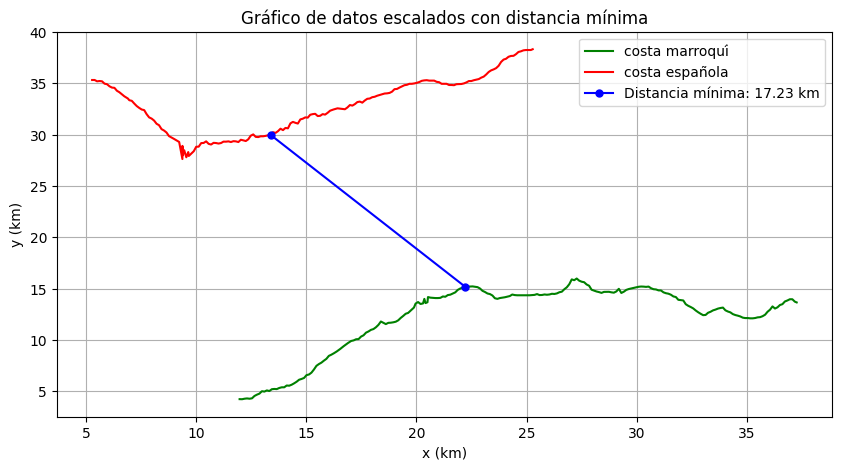

In [40]:
colores = ['green', 'red']
plt.figure(figsize=(10, 5))

for (nombre_archivo, df), color in zip(datos_archivos.items(), colores):
  df_to_plot = df_escalado[nombre_archivo]

  plt.plot(df_to_plot[nombres_columnas[0]], df_to_plot[nombres_columnas[1]], label=nombre_archivo, color = color)

if closest_points:
    (x_esp_closest, y_esp_closest), (x_mar_closest, y_mar_closest) = closest_points
    plt.plot([x_esp_closest, x_mar_closest], [y_esp_closest, y_mar_closest], 'bo-', label=f'Distancia mínima: {min_distance:.2f} km', markersize=5)

plt.xlabel(nombres_columnas[0])
plt.ylabel(nombres_columnas[1])
plt.title('Gráfico de datos escalados con distancia mínima')
plt.legend()
plt.grid(True)
plt.show()

La distancia real es de unos 14.5 km, entonces el error cometido es 19%, un resultado no aceptable. Para ello se debería calibrar mejor el escalado, para reducir la incertidumbre en la distancia.